In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

from pathlib import Path
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from stresscam.preprocessing.face_detection import FaceDetector
from stresscam.preprocessing.skin_segmentation import SkinSegmenter
from stresscam.preprocessing.rgb_extraction import RGBExtractor

In [2]:
dataset = Path("../data/raw/UBFC_Phys/s46")

video_path = dataset / "vid_s46_T1.avi"

In [3]:
detector = FaceDetector()
segmenter = SkinSegmenter()
extractor = RGBExtractor()

In [4]:
cap = cv2.VideoCapture(str(video_path))

n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

print(f"Frames : {n_frames}")
print(f"FPS    : {fps:.2f}")
print(f"Duration : {n_frames/fps:.2f} sec")

Frames : 6325
FPS    : 35.14
Duration : 180.00 sec


In [5]:
ret, frame = cap.read()

results = detector.detect(frame)
face = detector.crop(frame, results)

results = segmenter.detect_landmarks(face)

mask = segmenter.create_face_mask(face, results)
mask = segmenter.remove_features(mask, results)

skin = segmenter.apply_mask(face, mask)

rgb = extractor.extract(face, mask)

print(rgb)

[166.965415   123.2404399  108.80751159]


c:\Users\lason\.conda\envs\stresscam\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


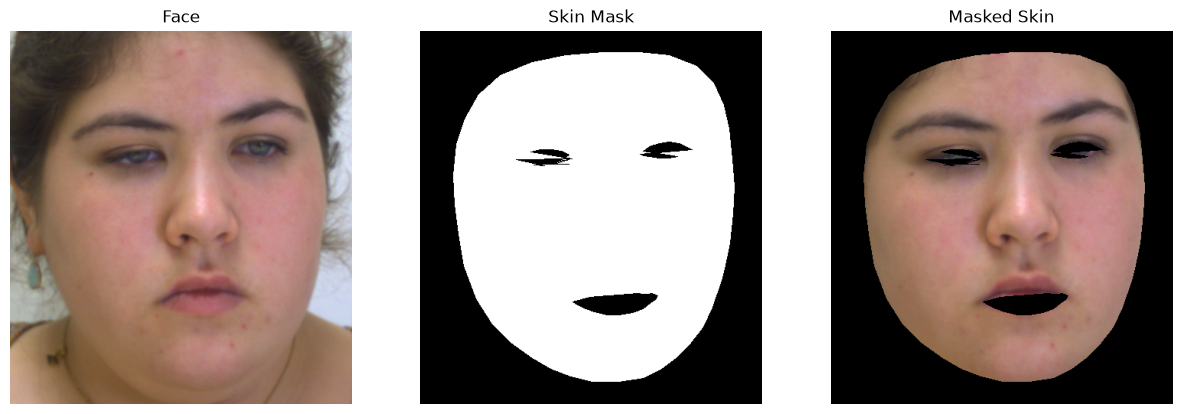

Mean RGB : [166.965415   123.2404399  108.80751159]


In [6]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
ax[0].set_title("Face")
ax[0].axis("off")

ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Skin Mask")
ax[1].axis("off")

ax[2].imshow(cv2.cvtColor(skin, cv2.COLOR_BGR2RGB))
ax[2].set_title("Masked Skin")
ax[2].axis("off")

plt.show()

print(f"Mean RGB : {rgb}")

In [7]:
R = []
G = []
B = []

failed_frames = []

In [8]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

for i in tqdm(range(n_frames)):

    ret, frame = cap.read()

    if not ret:
        failed_frames.append(i)
        continue

    try:
        # Face Detection
        det_results = detector.detect(frame)
        face = detector.crop(frame, det_results)

        if face is None:
            failed_frames.append(i)
            continue

        # Skin Segmentation
        mesh_results = segmenter.detect_landmarks(face)

        if not mesh_results.multi_face_landmarks:
            failed_frames.append(i)
            continue

        mask = segmenter.create_face_mask(face, mesh_results)
        mask = segmenter.remove_features(mask, mesh_results)

        # RGB Extraction
        rgb = extractor.extract(face, mask)

        if rgb is None:
            failed_frames.append(i)
            continue

        R.append(rgb[0])
        G.append(rgb[1])
        B.append(rgb[2])

    except Exception:
        failed_frames.append(i)

cap.release()

100%|██████████| 6325/6325 [03:48<00:00, 27.68it/s]


In [9]:
print(f"Processed frames : {len(R)}")
print(f"Failed frames    : {len(failed_frames)}")

Processed frames : 6325
Failed frames    : 0


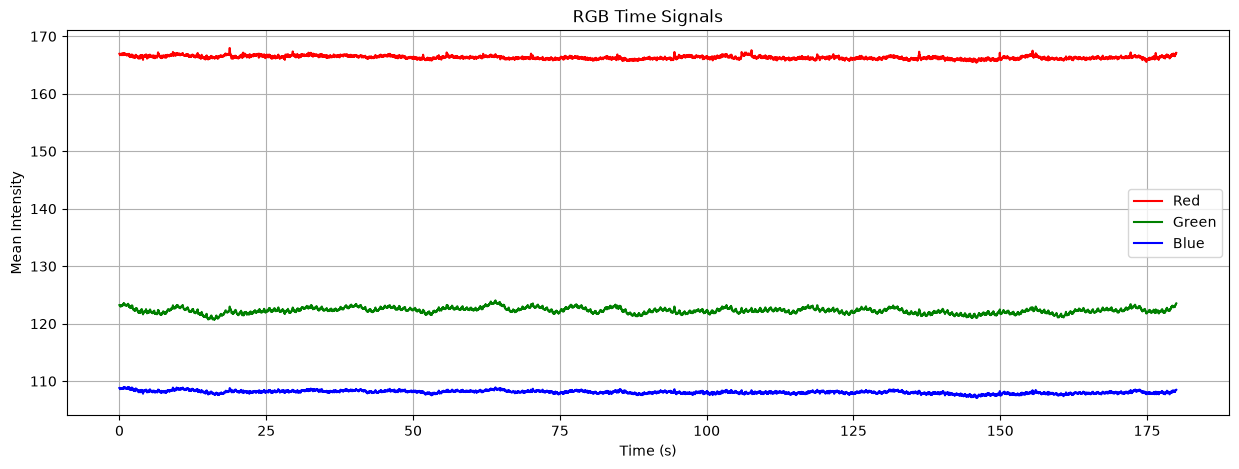

In [11]:
t = np.arange(len(R)) / fps

plt.figure(figsize=(15, 5))

plt.plot(t, R, label="Red", color="red")
plt.plot(t, G, label="Green", color="green")
plt.plot(t, B, label="Blue", color="blue")

plt.xlabel("Time (s)")
plt.ylabel("Mean Intensity")
plt.title("RGB Time Signals")

plt.legend()
plt.grid(True)

plt.show()

---
Plotting centered signals

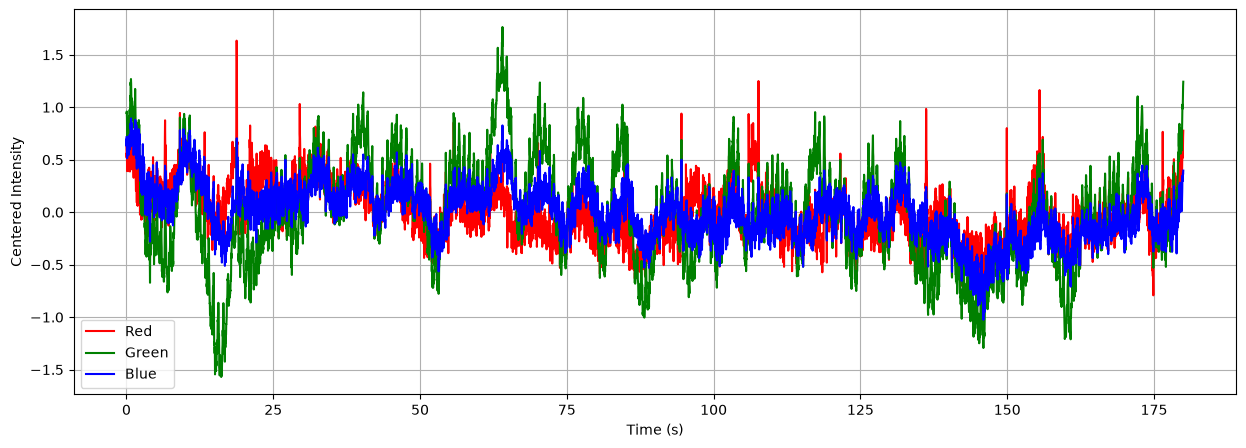

In [18]:
R0 = np.array(R) - np.mean(R)
G0 = np.array(G) - np.mean(G)
B0 = np.array(B) - np.mean(B)


plt.figure(figsize=(15,5))

plt.plot(t, R0, label="Red", color="red")
plt.plot(t, G0, label="Green", color="green")
plt.plot(t, B0, label="Blue", color="blue")

plt.xlabel("Time (s)")
plt.ylabel("Centered Intensity")
plt.legend()
plt.grid(True)

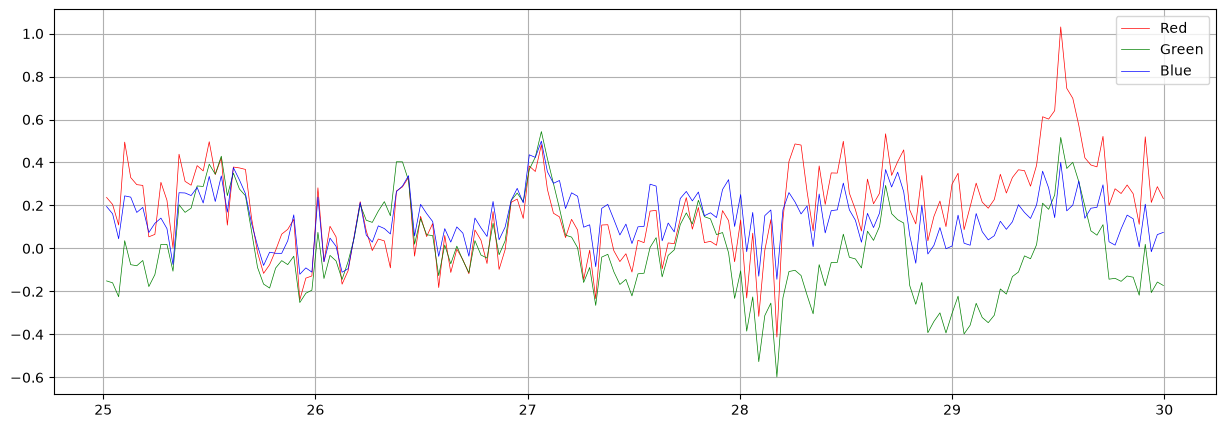

In [20]:
mask = (25 <= t) & (t <= 30)

plt.figure(figsize=(15,5))

plt.plot(t[mask], R0[mask], label="Red", color="red", linewidth=0.5)
plt.plot(t[mask], G0[mask], label="Green", color="green", linewidth=0.5)
plt.plot(t[mask], B0[mask], label="Blue", color="blue", linewidth=0.5)

plt.grid(True)
plt.legend()